In [116]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt


In [117]:
num_sm = 86
ffn_hidden_size = 2048
block_size = 128

In [118]:
block_bins = np.array([17, 33, 49, 65, 83, 99, 116, 132], dtype=np.int32)
num_row_block = block_bins[-1]
num_col_block = ffn_hidden_size // block_size
num_block = num_row_block * num_col_block

In [119]:
residual_block_idx = np.zeros(shape=(len(block_bins) * num_col_block))

for i in range(len(block_bins)):
    residual_block_idx[i * num_col_block: i * num_col_block + num_col_block] = \
    np.array(range(num_col_block)) + (block_bins[i] - 1) * num_col_block

## 假如让Residual block 存留在每个Expert的后面

In [120]:
integer_unit = {k: 0 for k in range(num_sm)}
residual_unit = {k: 0 for k in range(num_sm)}

block_idx = 0
for i in range(math.ceil(num_block / num_sm)):
    for j in range(num_sm):
        if block_idx < num_block:
            if block_idx in residual_block_idx:
                residual_unit[j] += 1
            else:
                integer_unit[j] += 1
            block_idx += 1

[4 4 4 4 4 4 4 4 3 3 2 2 1 1 0 0 0 0 0 0 1 1 2 2 2 2 2 2 2 2 2 2 3 3 4 4 3
 3 2 2 2 2 2 2 2 2 2 2 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 2 2 3 3 4 4]


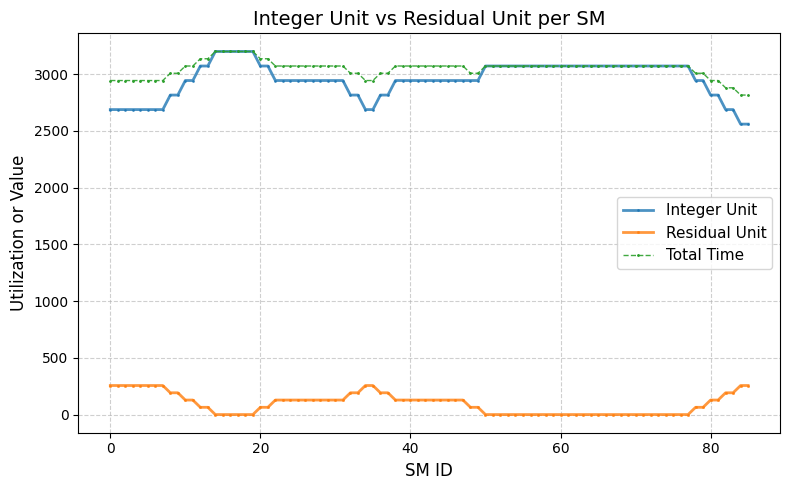

In [121]:
sm_ids = np.array(list(integer_unit.keys()))
integer_vals = np.array(list(integer_unit.values()))
residual_vals = np.array(list(residual_unit.values()))

print(residual_vals)

integer_weight = 128
residual_weight = 64

integer_vals_weight = integer_vals * integer_weight
residual_vals_weight = residual_vals * residual_weight

# 绘图
plt.figure(figsize=(8, 5))
plt.plot(sm_ids, integer_vals_weight, color='#1f77b4', marker='o', markersize=1,
         linewidth=2, alpha=0.8, label='Integer Unit')
plt.plot(sm_ids, residual_vals_weight, color='#ff7f0e', marker='s', markersize=1,
         linewidth=2, alpha=0.8, label='Residual Unit')
plt.plot(sm_ids, integer_vals_weight + residual_vals_weight, color='#2ca02c',
         marker='D', markersize=1, linestyle='--', linewidth=1, alpha=0.9, label='Total Time')

# 样式美化
plt.title('Integer Unit vs Residual Unit per SM', fontsize=14)
plt.xlabel('SM ID', fontsize=12)
plt.ylabel('Utilization or Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

## 假如是因为是residual block 全部放在最后面

In [122]:
integer_unit = {k: 0 for k in range(num_sm)}
residual_unit = {k: 0 for k in range(num_sm)}

block_idx = 0
for i in range(math.ceil(num_block / num_sm)):
    for j in range(num_sm):
        if block_idx < num_block:
            if block_idx > (num_block - len(block_bins) * num_col_block):
                residual_unit[j] += 1
            else:
                integer_unit[j] += 1
            block_idx += 1

[1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1]


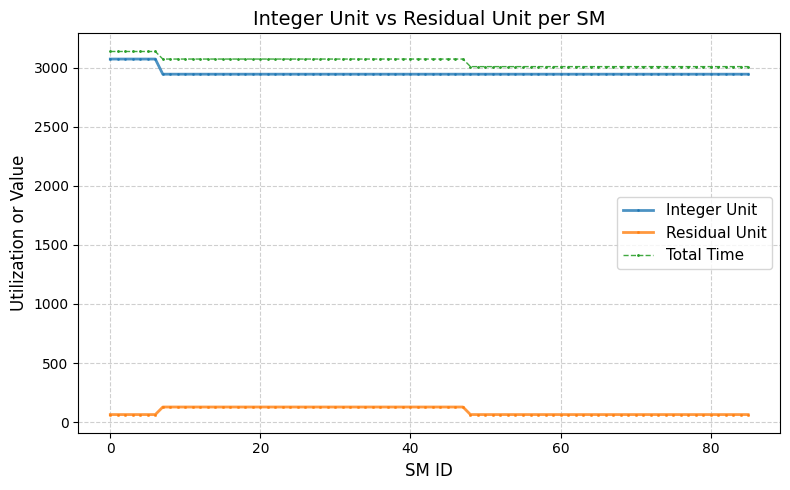

In [123]:
sm_ids = np.array(list(integer_unit.keys()))
integer_vals = np.array(list(integer_unit.values()))
residual_vals = np.array(list(residual_unit.values()))

print(residual_vals)

integer_weight = 128
residual_weight = 64

integer_vals_weight = integer_vals * integer_weight
residual_vals_weight = residual_vals * residual_weight

# 绘图
plt.figure(figsize=(8, 5))
plt.plot(sm_ids, integer_vals_weight, color='#1f77b4', marker='o', markersize=1,
         linewidth=2, alpha=0.8, label='Integer Unit')
plt.plot(sm_ids, residual_vals_weight, color='#ff7f0e', marker='s', markersize=1,
         linewidth=2, alpha=0.8, label='Residual Unit')
plt.plot(sm_ids, integer_vals_weight + residual_vals_weight, color='#2ca02c',
         marker='D', markersize=1, linestyle='--', linewidth=1, alpha=0.9, label='Total Time')

# 样式美化
plt.title('Integer Unit vs Residual Unit per SM', fontsize=14)
plt.xlabel('SM ID', fontsize=12)
plt.ylabel('Utilization or Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()